# Fixed-horizon vs anytime-valid: how the methods differ by effect size

A natural intuition is *“sequential / e-value tests should reach a verdict sooner, so I should always use them.”* That is half-right, and this notebook shows exactly where it holds and where it does not.

**The key fact.** At a *fixed* sample size, the fixed-horizon test is the more **powerful** one — it spends its entire error budget on a single look. The anytime-valid betting e-process must instead keep the guarantee valid at *every* look (so you may peek and stop early); it pays for that freedom by needing **more** evidence to reject. Its real advantage is therefore **early stopping / smaller expected sample size** on clear effects, plus the licence to monitor continuously — not extra power at a pre-set N.

Acronyms: **CI** = confidence interval, **SE** = standard error, **MDE** = minimum detectable effect, **N** = sample size.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from lerobot_doctor import compare_success, Trial

# The e-process accumulates 'wealth'; under very strong evidence it can exceed
# floating-point range and numpy prints a cosmetic overflow warning. The
# decision logic is unaffected, so we silence just that message for clean output.
warnings.filterwarnings('ignore', message='overflow encountered in exp')

AV = 'anytime-valid-betting-e-process'
FX = 'fixed-horizon-proportion-z-test'
ALPHA = 0.05

def make_dataset(rate_A, rate_B, n, seed=0):
    """Paired synthetic rollouts (same scene attempted by A and B)."""
    rng = np.random.default_rng(seed)
    A = [Trial(success=int(rng.random() < rate_A), key=k) for k in range(n)]
    B = [Trial(success=int(rng.random() < rate_B), key=k) for k in range(n)]
    return A, B

## Experiment A — same data, both methods, a *modest* effect

Policy A is a little better (65% vs 55%) and we collect N = 800 paired scenes.

In [2]:
A, B = make_dataset(0.65, 0.55, 800, seed=0)
fx = compare_success(A, B, method=FX, alpha=ALPHA, rng=np.random.default_rng(1))
av = compare_success(A, B, method=AV, alpha=ALPHA, rng=np.random.default_rng(1))

print(f"fixed-horizon : decided={fx.decided}   p-value={fx.p_value:.4f}")
print(f"anytime-valid : decided={av.decided}   e-value={av.e_value:.1f}   "
      f"must reach {av.e_threshold:.0f} (= 2/alpha)")

fixed-horizon : decided=True   p-value=0.0010
anytime-valid : decided=False   e-value=1.4   must reach 40 (= 2/alpha)


The fixed-horizon test calls a winner; the e-process does not (yet). That is **not a bug** — it is the price of peeking. For a two-sided test at `alpha = 0.05` the e-process splits its budget across both directions, so the honest decision bar is `2 / alpha = 40` in wealth (Ville's inequality), far above the evidence a modest effect accrues at N = 800.

## Experiment B — the e-process's real win: *early stopping*

Now let the effect grow. For each effect size we run the e-process on a long stream (N = 2000) and record **when** it stops — `n_to_decision`. A fixed-horizon test, by construction, always uses all N.

In [3]:
deltas = [0.0, 0.03, 0.05, 0.08, 0.12, 0.18, 0.25]   # A's edge over B (=0.45)
base = 0.45
stops = []
for d in deltas:
    A, B = make_dataset(base + d, base, 2000, seed=2)
    r = compare_success(A, B, method=AV, alpha=ALPHA, rng=np.random.default_rng(3))
    stops.append(r.n_to_decision if r.n_to_decision else np.nan)

for d, s in zip(deltas, stops):
    txt = f"{s:.0f} pairs" if s == s else "no decision within N=2000"
    print(f"effect {d*100:4.0f} pts -> {txt}")

effect    0 pts -> no decision within N=2000
effect    3 pts -> no decision within N=2000
effect    5 pts -> no decision within N=2000
effect    8 pts -> 780 pairs
effect   12 pts -> 302 pairs
effect   18 pts -> 124 pairs
effect   25 pts -> 27 pairs


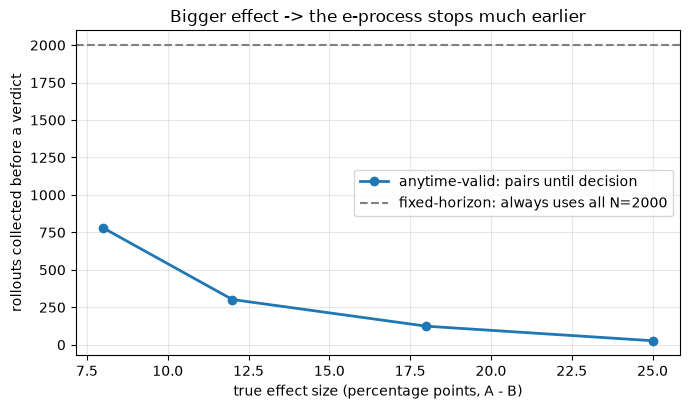

In [4]:
plt.figure(figsize=(7, 4.2))
x = [d * 100 for d in deltas]
plt.plot(x, stops, 'o-', lw=2, label='anytime-valid: pairs until decision')
plt.axhline(2000, ls='--', color='gray', label='fixed-horizon: always uses all N=2000')
plt.xlabel('true effect size (percentage points, A - B)')
plt.ylabel('rollouts collected before a verdict')
plt.title('Bigger effect -> the e-process stops much earlier')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Small effects: the e-process may never cross the bar within N (the `NaN`s), so fixed-horizon is the better choice. **Large effects: it stops in a few dozen rollouts** — collecting (and labelling) a fraction of the data a fixed test would demand. That early stopping is the entire point.

### The wealth trajectory behind a single early stop

On a strong effect (75% vs 45%) the e-process's evidence (“wealth”) shoots past the decision bar within a handful of pairs.

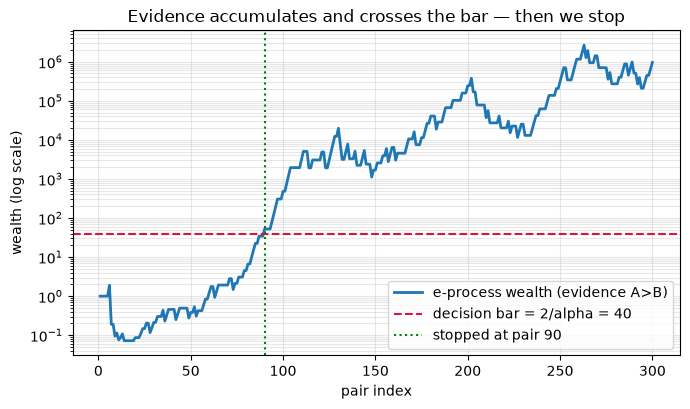

In [5]:
A, B = make_dataset(0.75, 0.45, 300, seed=4)
r = compare_success(A, B, method=AV, alpha=ALPHA, rng=np.random.default_rng(5))
w = r.wealth_AgtB

plt.figure(figsize=(7, 4.2))
plt.plot(range(1, len(w) + 1), w, lw=2, label='e-process wealth (evidence A>B)')
plt.axhline(r.e_threshold, ls='--', color='crimson',
            label=f'decision bar = 2/alpha = {r.e_threshold:.0f}')
if r.n_to_decision:
    plt.axvline(r.n_to_decision, ls=':', color='green',
                label=f'stopped at pair {r.n_to_decision}')
plt.yscale('log'); plt.xlabel('pair index'); plt.ylabel('wealth (log scale)')
plt.title('Evidence accumulates and crosses the bar — then we stop')
plt.legend(); plt.grid(alpha=0.3, which='both'); plt.tight_layout(); plt.show()

## Experiment C — give the modest effect more data

The e-process is not *unable* to call the 65%-vs-55% effect; it just needs enough total evidence to clear the high bar. Sweep N and watch it cross.

In [6]:
Ns = [800, 1500, 2500, 4000]
print(f"{'N':>6} | {'anytime-valid e-value':>22} | decided | {'stop@':>6}")
print('-' * 52)
for N in Ns:
    A, B = make_dataset(0.65, 0.55, N, seed=6)
    r = compare_success(A, B, method=AV, alpha=ALPHA, rng=np.random.default_rng(7))
    stop = r.n_to_decision if r.n_to_decision else '-'
    print(f"{N:>6} | {r.e_value:>22.1f} | {str(r.decided):>7} | {str(stop):>6}")

     N |  anytime-valid e-value | decided |  stop@
----------------------------------------------------


   800 |               360144.0 |    True |    567


  1500 |                 4409.8 |    True |    915


  2500 |         152545708129.8 |    True |    802


  4000 |  1510416822689773056.0 |    True |    674


## Experiment D — power and minimum detectable effect (fixed-horizon)

The fixed-horizon report tells you, at your realised sample size, the achieved **power** (chance of catching the effect) and the **MDE** (smallest effect you could reliably detect). Both improve as N grows.

In [7]:
print(f"{'N':>6} | {'power':>6} | {'MDE (pts)':>9} | {'p-value':>8}")
print('-' * 40)
for N in [400, 800, 1600, 3200]:
    A, B = make_dataset(0.65, 0.55, N, seed=8)
    r = compare_success(A, B, method=FX, alpha=ALPHA, rng=np.random.default_rng(9))
    print(f"{N:>6} | {r.power:>6.2f} | {r.mde*100:>9.1f} | {r.p_value:>8.4f}")

     N |  power | MDE (pts) |  p-value
----------------------------------------
   400 |   0.61 |       9.7 |   0.0257
   800 |   0.99 |       7.0 |   0.0000
  1600 |   1.00 |       4.7 |   0.0000
  3200 |   1.00 |       3.4 |   0.0000


## Takeaways — which method when

| Situation | Use |
|---|---|
| You will look once, at a pre-planned N | **fixed-horizon-proportion-z-test** — maximum power per look |
| You want to monitor live and **stop as soon as** it's conclusive | **anytime-valid-betting-e-process** — peeking is free |
| Effect is expected to be **large** / labels are expensive | **anytime-valid** — it stops early and saves data |
| Effect is **subtle** and N is limited | **fixed-horizon** — it resolves smaller effects at a fixed N |

Both report the same scorecard (lift, CI, relative lift, Sample Ratio Mismatch check, Bayesian P(A beats B)), so you can switch methods with one argument and compare like for like.